In [28]:
from typing import TypedDict
from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

from langchain_huggingface import HuggingFaceEndpoint
from langchain_core.messages import HumanMessage

load_dotenv()

True

In [29]:
import os
from dotenv import load_dotenv
from huggingface_hub import InferenceClient

load_dotenv()


class HuggingFaceLLM:

    def __init__(
        self,
        model_name="Qwen/Qwen2.5-7B-Instruct",
        api_key=None,
    ):

        self.model_name = model_name

        self.client = InferenceClient(
            api_key=api_key or os.getenv("HF_TOKEN")
        )

    def invoke(self, prompt: str) -> str:

        response = self.client.chat.completions.create(
            model=self.model_name,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ]
        )

        return response.choices[0].message.content
    
llm = HuggingFaceLLM()

In [30]:
class state(TypedDict):
    joke: str
    explanation: str

In [31]:
def make_joke(state:state):
    prompt = f"Make a joke about {state['joke']}"
    joke = llm.invoke(prompt)
    return {"joke": joke}

In [32]:
def explain_joke(state:state):
    prompt = f"explain the joke. Joke--{state['joke']}"
    explaination = llm.invoke(prompt)
    return {"explanation": explaination}

In [33]:
graph = StateGraph(state)

graph.add_node("make_joke", make_joke)
graph.add_node("explain_joke", explain_joke)

graph.add_edge(START,"make_joke")
graph.add_edge("make_joke","explain_joke")
graph.add_edge("explain_joke",END)

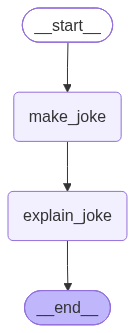

In [34]:
workflow

In [35]:
from langgraph.checkpoint.memory import MemorySaver
checkpointer = MemorySaver()
workflow = graph.compile(checkpointer=checkpointer)

In [36]:
config = {
    "configurable": {
        "thread_id": "user123"
    }
}

In [37]:
workflow.invoke({"joke": "chicken crossing the road"},config=config)

{'joke': 'Why did the chicken cross the road twice? \n\nTo get to the other side... and then to prove to everyone that he could do it!',
 'explanation': 'This joke is a play on a classic setup for a chicken crossing the road, but with an added twist. The first part of the joke, "Why did the chicken cross the road? To get to the other side," is a familiar and simple setup. The punchline, "and then to prove to everyone that he could do it!" adds a humorous and unexpected element. It suggests that the chicken\'s motivation was not just to reach the other side, but to demonstrate its ability to cross the road, which adds a layer of comedy through the chicken\'s perceived pride or determination.'}

In [38]:
workflow.invoke({"joke": "salman khan"},config=config)

{'joke': "Sure, here's a light-hearted joke for you:\n\nWhy did Salman Khan need a special kind of map?\n\nBecause he was always getting lost in his own stardom!",
 'explanation': 'This joke is a play on words and a reference to the actor Salman Khan, who is well-known in the Indian film industry and has a significant fan base. The humor comes from the idea that Salman Khan, being a famous and popular actor, often finds himself so engrossed in his stardom that he gets "lost" in it, metaphorically speaking. The punchline, "Because he was always getting lost in his own stardom!" is a clever way to suggest that his fame and popularity are so overwhelming that he might have trouble navigating the personal and professional aspects of his life, much like one might get lost using a regular map in an unfamiliar place.'}

In [39]:
state = workflow.get_state(config)

print(state)

StateSnapshot(values={'joke': "Sure, here's a light-hearted joke for you:\n\nWhy did Salman Khan need a special kind of map?\n\nBecause he was always getting lost in his own stardom!", 'explanation': 'This joke is a play on words and a reference to the actor Salman Khan, who is well-known in the Indian film industry and has a significant fan base. The humor comes from the idea that Salman Khan, being a famous and popular actor, often finds himself so engrossed in his stardom that he gets "lost" in it, metaphorically speaking. The punchline, "Because he was always getting lost in his own stardom!" is a clever way to suggest that his fame and popularity are so overwhelming that he might have trouble navigating the personal and professional aspects of his life, much like one might get lost using a regular map in an unfamiliar place.'}, next=(), config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f1916cd-7ec3-6655-8006-cea78b2db841'}}, metadata={'source

In [40]:
list(workflow.get_state_history(config))

[StateSnapshot(values={'joke': "Sure, here's a light-hearted joke for you:\n\nWhy did Salman Khan need a special kind of map?\n\nBecause he was always getting lost in his own stardom!", 'explanation': 'This joke is a play on words and a reference to the actor Salman Khan, who is well-known in the Indian film industry and has a significant fan base. The humor comes from the idea that Salman Khan, being a famous and popular actor, often finds himself so engrossed in his stardom that he gets "lost" in it, metaphorically speaking. The punchline, "Because he was always getting lost in his own stardom!" is a clever way to suggest that his fame and popularity are so overwhelming that he might have trouble navigating the personal and professional aspects of his life, much like one might get lost using a regular map in an unfamiliar place.'}, next=(), config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f1916cd-7ec3-6655-8006-cea78b2db841'}}, metadata={'sourc

#### **Time Travel**

In [51]:
config = {
    "configurable": {
        "thread_id": "user123",
        "checkpoint_id": "1f1916cd-5675-6d92-8000-784566085594"
    
    }
}

state = workflow.get_state(config)
print(state)

StateSnapshot(values={'joke': 'chicken crossing the road'}, next=('make_joke',), config={'configurable': {'thread_id': 'user123', 'checkpoint_id': '1f1916cd-5675-6d92-8000-784566085594'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-08-06T08:00:04.801268+00:00', parent_config={'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f1916cd-5675-6d91-bfff-8e9edb0625cb'}}, tasks=(PregelTask(id='f71fc05b-7710-f4c3-ef3f-8da7d3b96eaa', name='make_joke', path=('__pregel_pull', 'make_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the chicken cross the road twice? \n\nTo get to the other side... and then to prove to everyone that he could do it!'}),), interrupts=())


In [60]:
config = {
    "configurable": {
        "thread_id": "user123",
        "checkpoint_ns": "",
        "checkpoint_id": "1f1916cd-5675-6d92-8000-784566085594"
    }
}

workflow.update_state(
    config,
    {
        "joke": "Batman and Superman"
    }
)

{'configurable': {'thread_id': 'user123',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1916ed-cf94-6c15-8001-1abf7c7ee931'}}

In [61]:
new_config = workflow.update_state(
    config,
    {
        "joke": "Batman and Superman"
    }
)
print(new_config)

{'configurable': {'thread_id': 'user123', 'checkpoint_ns': '', 'checkpoint_id': '1f1916ed-e192-60b3-8001-4f303885d102'}}


In [62]:
new_state = workflow.get_state(new_config)
print(new_state.values)

{'joke': 'Batman and Superman'}


In [63]:
state = workflow.get_state(config)
print(state.values)

{'joke': 'chicken crossing the road'}


In [64]:
workflow.invoke(None, config=new_config)

{'joke': "Sure! Here's a light-hearted joke for you:\n\nWhy did Batman break up with Superman?\n\nBecause every time they had a fight, Clark just flew away!",
 'explanation': 'This joke plays on the contrast between Batman and Superman\'s personalities and abilities. Batman is known for his fighting skills, detective work, and his tendency to engage in physical confrontations. On the other hand, Superman has the ability to fly, which in this context is portrayed as a way to avoid conflict rather than to resolve it.\n\nThe punchline, "Because every time they had a fight, Clark just flew away!" is a humorous take on how Superman\'s ability to fly can be seen as a way to avoid confrontation or responsibility, which is not the typical behavior expected from a superhero like Batman who is more inclined to face challenges head-on. This contrast creates a funny and lighthearted situation that pokes fun at the characters\' typical traits and abilities.'}